# 06 · CEvNS acceptance study

            Replaces `Acceptance_analyst.ipynb`. Aggregates the per-batch
            ``acceptance_e<N>.npz`` files produced by ``scripts/run_acceptance.py`` and
            plots acceptance vs S2 area for each electron multiplicity.

In [1]:
# Auto-discover the package even if the notebook is launched from outside the repo.
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110

In [2]:
from pathlib import Path
ACC_DIR = Path('../outputs/acceptance')
files = sorted(ACC_DIR.glob('batch_*/acceptance_e*.npz'))
assert files, 'Run scripts/run_acceptance.py first to populate outputs/acceptance/.'

## 1 – Aggregate

In [3]:
from collections import defaultdict
per_n = defaultdict(list)
for fp in files:
    d = np.load(fp)
    per_n[int(d['e_num'][0])].append(d)

for n in sorted(per_n):
    area = np.concatenate([d['area'] for d in per_n[n]])
    print(f'n_e={n}: {len(area)} events surviving the pattern cut')

n_e=1: 14 events surviving the pattern cut
n_e=2: 443 events surviving the pattern cut
n_e=3: 344 events surviving the pattern cut
n_e=4: 177 events surviving the pattern cut
n_e=5: 94 events surviving the pattern cut
n_e=6: 36 events surviving the pattern cut
n_e=7: 10 events surviving the pattern cut
n_e=8: 3 events surviving the pattern cut
n_e=9: 1 events surviving the pattern cut
n_e=10: 1 events surviving the pattern cut


## 2 – Acceptance vs area

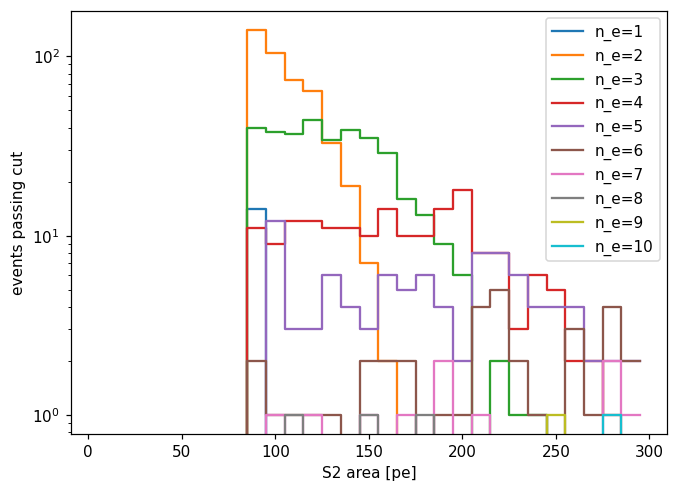

In [4]:
bins = np.linspace(0, 300, 31)
fig, ax = plt.subplots(figsize=(7, 5))
for n in sorted(per_n):
    area = np.concatenate([d['area'] for d in per_n[n]])
    hist, edges = np.histogram(area, bins=bins)
    ax.step(0.5*(edges[1:]+edges[:-1]), hist, label=f'n_e={n}')
ax.set_xlabel('S2 area [pe]')
ax.set_ylabel('events passing cut')
ax.set_yscale('log')
ax.legend()
plt.show()

## 3 – Combined acceptance figure

            We typically combine the bins into a single acceptance-vs-area curve weighted
            by the assumed CEvNS spectrum.  Adapt the snippet below to your weighting.

In [5]:
spectrum_path = '../data/e_spectrum_relics.npz'
spec = np.load(spectrum_path)
print('spectrum bins:', spec['CEvNS_bins'])
print('spectrum counts:', spec['CEvNS'])

spectrum bins: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
spectrum counts: [8.92738025e+04 7.24821089e+03 1.89479144e+03 7.09425689e+02
 3.05977230e+02 1.38771544e+02 6.34963142e+01 2.87346663e+01
 1.27261607e+01 5.48180895e+00 2.28769727e+00 9.22707794e-01
 3.59159319e-01 1.34810976e-01 4.87796055e-02 1.70148066e-02
 5.72258400e-03 1.85654875e-03 5.81291872e-04 1.75759218e-04]
